In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np

Re=100
  max CL = 1.934879
  Time_Iter at max CL = 220

Re=200
  max CL = 2.443430
  Time_Iter at max CL = 462

Re=300
  max CL = 2.045293
  Time_Iter at max CL = 484

Re=400
  max CL = 2.165976
  Time_Iter at max CL = 477



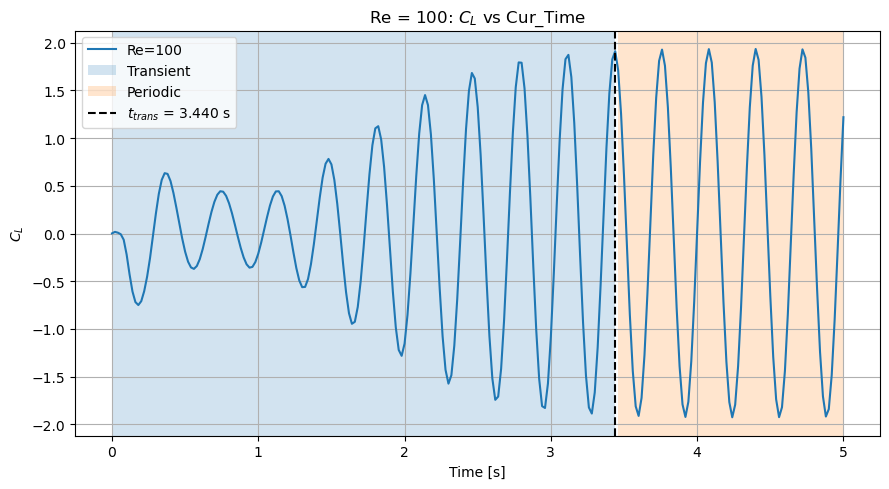

Saved: Outputs\CL_vs_time_Re_100.pdf
transient cutoff time: 3.44 s
cl_max_5: 1.934879152


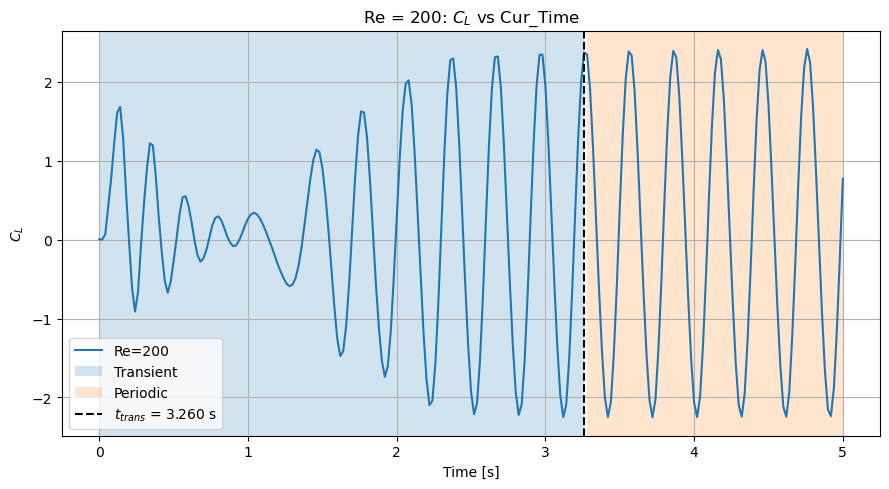

Saved: Outputs\CL_vs_time_Re_200.pdf
transient cutoff time: 3.26 s
cl_max_5: 2.41387436


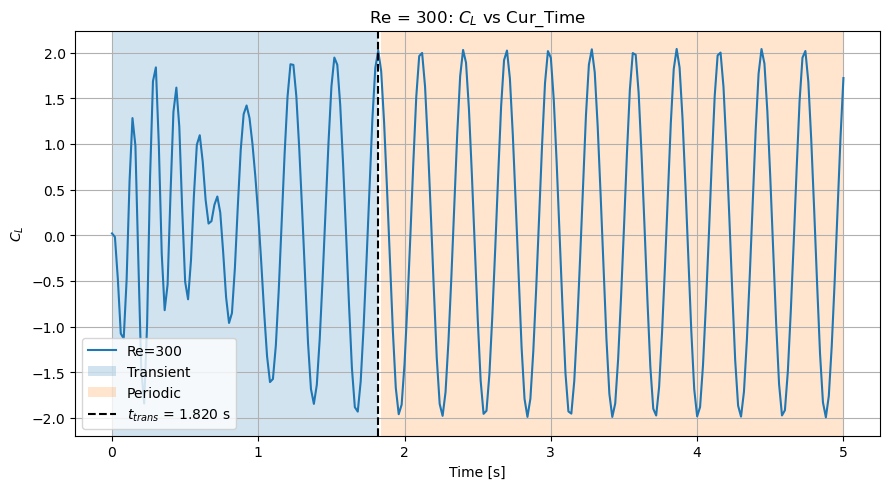

Saved: Outputs\CL_vs_time_Re_300.pdf
transient cutoff time: 1.82 s
cl_max_5: 2.040574


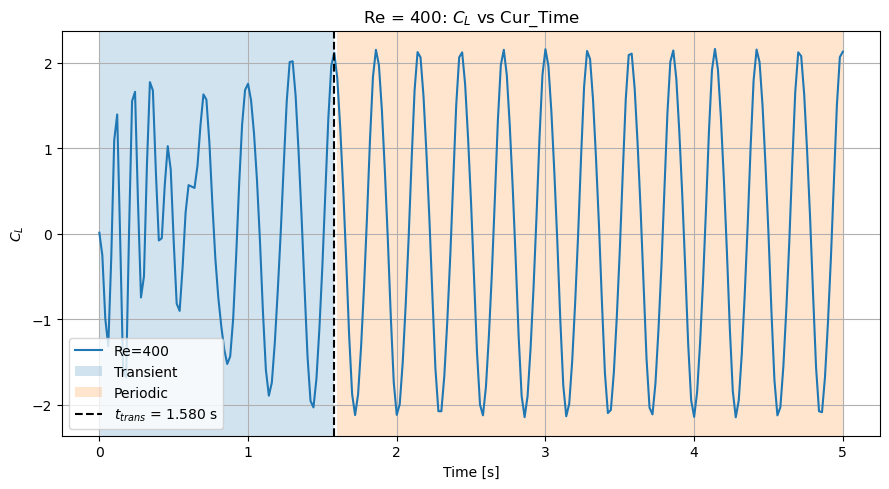

Saved: Outputs\CL_vs_time_Re_400.pdf
transient cutoff time: 1.58 s
cl_max_5: 2.163688114


In [48]:
# Reynolds-number folders to check
re_cases = [100, 200, 300, 400]

# dirs
base_dir = Path("./CFD")
output_dir = Path("./Outputs")
output_dir.mkdir(exist_ok=True)

# store data if we want to use it later
case_data = {}

for Re in re_cases:
    csv_path = base_dir / f"Re={Re}" / "history.csv"
    
    if not csv_path.exists():
        print(f"Re={Re}: history.csv not found at {csv_path}")
        continue
    
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip().str.replace('"', '', regex=False)
    
    case_data[Re] = df
    
    idx_max = df["CL"].idxmax()
    time_iter_at_max = df.loc[idx_max, "Time_Iter"]
    cl_max = df.loc[idx_max, "CL"]
    
    print(f"Re={Re}")
    print(f"  max CL = {cl_max:.6f}")
    print(f"  Time_Iter at max CL = {time_iter_at_max}")
    print()


for Re, df in case_data.items():
    df_5 = df[df["Cur_Time"] <= 5.0].copy()
    
    if df_5.empty:
        continue
    
    cl_max_5 = df_5["CL"].max()
    threshold = 0.975 * cl_max_5
    
    reached = df[df["CL"] >= threshold]
    
    if reached.empty:
        t_trans = None
    else:
        t_trans = df.loc[reached.index[0], "Cur_Time"]
    
    plt.figure(figsize=(9, 5))
    plt.plot(df_5["Cur_Time"], df_5["CL"], label=f"Re={Re}")
    
    y_min = df_5["CL"].min()
    y_max = df_5["CL"].max()
    
    # small padding so shading fully covers plot
    y_pad = 0.05 * (y_max - y_min)
    y_low = y_min - y_pad
    y_high = y_max + y_pad
    
    if t_trans is not None:
        # transient region
        plt.fill_between(df_5["Cur_Time"], y_low, y_high,
                         where=(df_5["Cur_Time"] <= t_trans),
                         alpha=0.2, label="Transient")
        
        # periodic region
        plt.fill_between(df_5["Cur_Time"], y_low, y_high,
                         where=(df_5["Cur_Time"] > t_trans),
                         alpha=0.2, label="Periodic")
        
        plt.axvline(t_trans, linestyle="--", color="k",
                    label=f"$t_{{trans}}$ = {t_trans:.3f} s")
        
        # # lower labels (near bottom)
        # x_left = 0.5 * (df_5["Cur_Time"].min() + t_trans)
        # x_right = 0.5 * (t_trans + df_5["Cur_Time"].max())
        # y_text = y_min + 0.1 * (y_max - y_min)
        
        # plt.text(x_left, y_text, "Transient", ha="center")
        # plt.text(x_right, y_text, "Periodic", ha="center")
    
    plt.ylim(y_low, y_high)
    plt.xlabel("Time [s]")
    plt.ylabel("$C_L$")
    plt.title(f"Re = {Re}: $C_L$ vs Cur_Time")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    
    save_path = output_dir / f"CL_vs_time_Re_{Re}.pdf"
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.show()
    
    print(f"Saved: {save_path}")
    print(f"transient cutoff time: {t_trans} s")
    print(f"cl_max_5: {cl_max_5}")

--------------------------


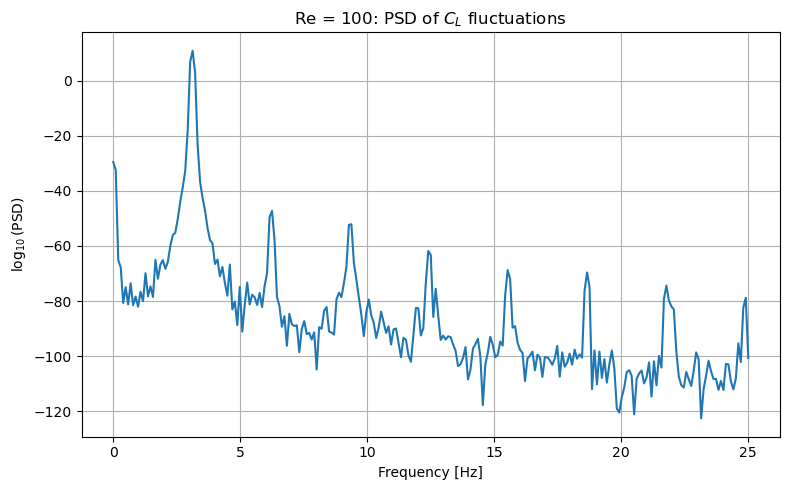

Re=100
  transient cutoff time = 3.1200 s
  periodic samples used = 510
  dominant frequency from PSD = 3.1250 Hz
  Strouhal Number St = 0.1837

  average period = 0.3213 s
  average frequency = 3.1120 Hz
  average amplitude = 1.9216
  max_cl = 1.9349
  number of peaks used = 30
  Strouhal Number from ave St = 0.1829

  saved: Outputs\PSD_CL_Re_100.pdf

--------------------------


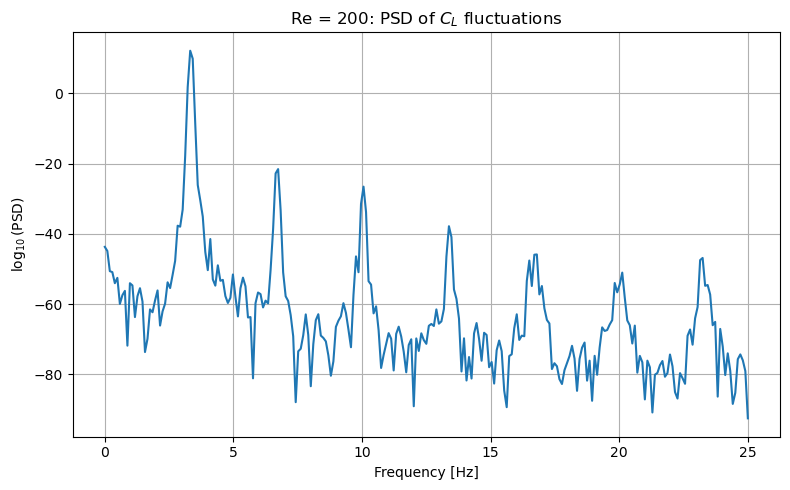

Re=200
  transient cutoff time = 2.9600 s
  periodic samples used = 522
  dominant frequency from PSD = 3.3203 Hz
  Strouhal Number St = 0.1951

  average period = 0.2988 s
  average frequency = 3.3469 Hz
  average amplitude = 2.4149
  max_cl = 2.4434
  number of peaks used = 33
  Strouhal Number from ave St = 0.1967

  saved: Outputs\PSD_CL_Re_200.pdf

--------------------------


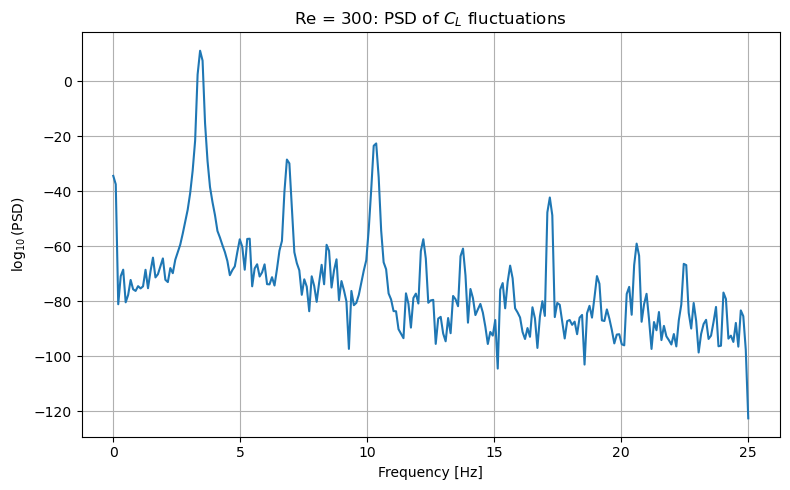

Re=300
  transient cutoff time = 1.5200 s
  periodic samples used = 592
  dominant frequency from PSD = 3.4180 Hz
  Strouhal Number St = 0.2009

  average period = 0.2913 s
  average frequency = 3.4331 Hz
  average amplitude = 2.0245
  max_cl = 2.0453
  number of peaks used = 39
  Strouhal Number from ave St = 0.2018

  saved: Outputs\PSD_CL_Re_300.pdf

--------------------------


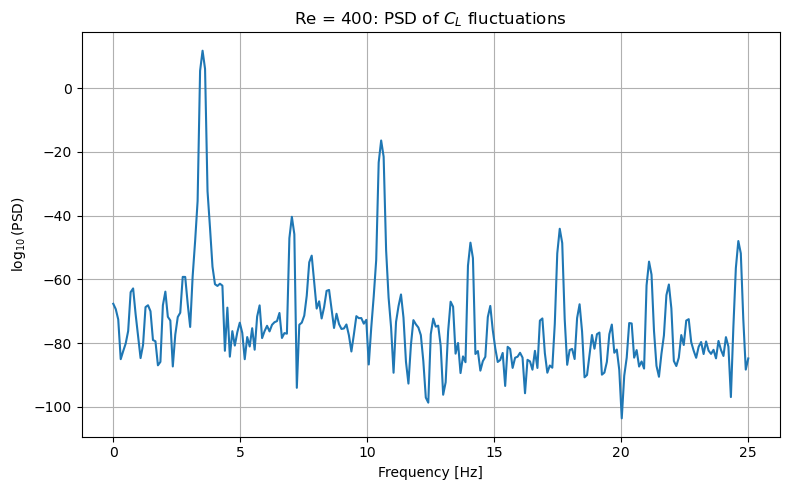

Re=400
  transient cutoff time = 1.5800 s
  periodic samples used = 589
  dominant frequency from PSD = 3.5156 Hz
  Strouhal Number St = 0.2066

  average period = 0.2845 s
  average frequency = 3.5149 Hz
  average amplitude = 2.1441
  max_cl = 2.1660
  number of peaks used = 40
  Strouhal Number from ave St = 0.2066

  saved: Outputs\PSD_CL_Re_400.pdf



In [55]:

dt = 0.02
fs = 1.0 / dt   # 50 Hz
NFFT = 512
D = 2 # m
U = 34.03 # m/s

for Re, df in case_data.items():
    print("--------------------------")
    # find average frequency
    # compute transient cutoff again
    cl_max = df["CL"].max()
    threshold = 0.95 * cl_max
    reached = df[df["CL"] >= threshold]
    
    if reached.empty:
        print(f"Re={Re}: no transient cutoff found")
        continue
    
    t_trans = df.loc[reached.index[0], "Cur_Time"]
    
    # periodic region
    df_periodic = df[df["Cur_Time"] > t_trans]
    
    t = df_periodic["Cur_Time"].values
    cl = df_periodic["CL"].values
    
    if len(t) < 10:
        print(f"Re={Re}: not enough data in periodic region")
        continue
    
    # find peaks in CL signal
    peaks, _ = find_peaks(cl)
    
    if len(peaks) < 2:
        print(f"Re={Re}: not enough peaks to compute frequency")
        continue
    
    # compute periods between peaks
    peak_times = t[peaks]
    periods = np.diff(peak_times)
    
    avg_period = np.mean(periods)
    freq = 1.0 / avg_period

    ave_amplitude = cl[peaks].mean()

    """
    Make power spectral density vs frequency plots
    
    """
    t = df_periodic["Cur_Time"].to_numpy()
    cl = df_periodic["CL"].to_numpy()
    
    # fluctuations in CL
    cl_fluct = cl - np.mean(cl)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Matplotlib psd demo style:
    Pxx, freqs = ax.psd(cl_fluct, NFFT=NFFT, Fs=fs)
    
    # replace default PSD line with explicit log10-basis plot
    ax.cla()
    ax.plot(freqs, 10 * np.log10(Pxx))
    
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(r"$\log_{10}(\mathrm{PSD})$")
    ax.set_title(f"Re = {Re}: PSD of $C_L$ fluctuations")
    ax.grid(True)
    plt.tight_layout()
    
    save_path = output_dir / f"PSD_CL_Re_{Re}.pdf"
    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.show()
    
    # dominant frequency from PSD peak, ignoring f = 0
    if len(freqs) > 1:
        i_peak = np.argmax(Pxx[1:]) + 1
        f_dom = freqs[i_peak]

        St = f_dom * D / U

        print(f"Re={Re}")
        print(f"  transient cutoff time = {t_trans:.4f} s")
        print(f"  periodic samples used = {len(cl_fluct)}")
        print(f"  dominant frequency from PSD = {f_dom:.4f} Hz")
        print(f"  Strouhal Number St = {St:.4f}")
        print()
        print(f"  average period = {avg_period:.4f} s")
        print(f"  average frequency = {freq:.4f} Hz")
        print(f"  average amplitude = {ave_amplitude:.4f}")
        print(f"  max_cl = {cl_max:.4f}")
        print(f"  number of peaks used = {len(periods)}")
        print(f"  Strouhal Number from ave St = {(freq * D / U):.4f}")
        print()
        print(f"  saved: {save_path}")
        print()

In [54]:
d1001 =  13.3817 - 4.7382
d1002 = 14.6509 - 6.03767
d2001 = 10.9864 - 3.24731
d2002 = 12.01 - 4.32828
d3001 = 11.8326 - 3.8215
d3002 = 12.7997 - 4.84899
d4001 = 10.2611 - 2.94511
d4002 = 11.3491 - 3.85173


# Averages
d100 = (d1001 + d1002) / 2
d200 = (d2001 + d2002) / 2
d300 = (d3001 + d3002) / 2
d400 = (d4001 + d4002) / 2

# Print results
print(f"d1001 = {d1001:.4f}, d1002 = {d1002:.4f}, avg = {d100:.4f}")
print(f"d2001 = {d2001:.4f}, d2002 = {d2002:.4f}, avg = {d200:.4f}")
print(f"d3001 = {d3001:.4f}, d3002 = {d3002:.4f}, avg = {d300:.4f}")
print(f"d4001 = {d4001:.4f}, d4002 = {d4002:.4f}, avg = {d400:.4f}")


d1001 = 8.6435, d1002 = 8.6132, avg = 8.6284
d2001 = 7.7391, d2002 = 7.6817, avg = 7.7104
d3001 = 8.0111, d3002 = 7.9507, avg = 7.9809
d4001 = 7.3160, d4002 = 7.4974, avg = 7.4067
